<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 4

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [34]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [35]:
import os
import time
import logging
import warnings

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
logging.getLogger('cmdstanpy').disabled = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.examples import get_stallion_data
from pytorch_forecasting.metrics import QuantileLoss

In [36]:
random_state = 333

np.random.seed(random_state)
torch.manual_seed(random_state)
pl.seed_everything(random_state, workers=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Current device: {device}')

Seed set to 333


Current device: cuda


# Problem 4.3: Temporal Fusion Transformer

## Objective

Use PyTorch Forecasting library:

## Tasks

- Apply TFT to a retail sales forecasting problem.
- Include static features (store location) and time-varying features (promotions, holidays).
- Analyze variable importance from the model.
- Generate probabilistic forecasts with quantile predictions.

We will use `get_stallion_data()` from PyTorch Forecasting. It is a retail sales panel with products, agencies, prices, discounts, holidays and location-level demographic features.

In [37]:
data = get_stallion_data()

data['time_idx'] = data['date'].dt.year * 12 + data['date'].dt.month
data['time_idx'] -= data['time_idx'].min()

data['month'] = data['date'].dt.month.astype(str).astype('category')
data['log_volume'] = np.log(data['volume'] + 1e-8)
data['avg_volume_by_sku'] = data.groupby(['time_idx', 'sku'], observed=True).volume.transform('mean')
data['avg_volume_by_agency'] = data.groupby(['time_idx', 'agency'], observed=True).volume.transform('mean')

data.head()

,agency,sku,volume,date,industry_volume,soda_volume,avg_max_temp,price_regular,price_actual,discount,...,football_gold_cup,beer_capital,music_fest,discount_in_percent,timeseries,time_idx,month,log_volume,avg_volume_by_sku,avg_volume_by_agency
0,Agency_22,SKU_01,52.2720,2013-01-01,492612703,718394219,25.845238,1168.903668,1069.166193,99.737475,...,0,0,0,8.532566,0,0,1,3.956461,2613.377501,103.805460
238,Agency_37,SKU_04,0.0000,2013-01-01,492612703,718394219,26.505000,1852.273642,1611.466298,240.807344,...,0,0,0,13.000635,5,0,1,-18.420681,1361.511918,0.549900
237,Agency_59,SKU_03,812.9214,2013-01-01,492612703,718394219,22.219737,1270.795012,1197.184260,73.610752,...,0,0,0,5.792496,9,0,1,6.700634,1225.306376,2041.909586
236,Agency_11,SKU_01,316.4400,2013-01-01,492612703,718394219,25.360000,1176.155397,1082.757488,93.397909,...,0,0,0,7.940950,14,0,1,5.757134,2613.377501,125.690220
235,Agency_05,SKU_05,420.9093,2013-01-01,492612703,718394219,24.079012,1327.003396,1207.822992,119.180404,...,0,0,0,8.981168,22,0,1,6.042417,1179.728165,1638.463500


In [38]:
data.shape

(21000, 31)

Special days are stored as one-hot columns. For TFT it is cleaner to encode them as one grouped categorical variable, following the idea from the lecture notebook.

In [39]:
event_cols = [col for col in data.columns if data[col].dropna().isin([0, 1]).all()]
event_cols

['easter_day',
 'good_friday',
 'new_year',
 'christmas',
 'labor_day',
 'independence_day',
 'revolution_day_memorial',
 'regional_games',
 'fifa_u_17_world_cup',
 'football_gold_cup',
 'beer_capital',
 'music_fest']

In [40]:
special_days = ['easter_day', 'good_friday', 'new_year', 'christmas', 'labor_day', 'independence_day', 'revolution_day_memorial', 'regional_games', 'fifa_u_17_world_cup', 'football_gold_cup', 'beer_capital', 'music_fest']
data[special_days] = (data[special_days].apply(lambda x: x.map({0: '-', 1: x.name})).astype('category'))

data[['date', 'agency', 'sku', 'volume', 'discount_in_percent', 'month'] + special_days[:3]].head()

,date,agency,sku,volume,discount_in_percent,month,easter_day,good_friday,new_year
0,2013-01-01,Agency_22,SKU_01,52.2720,8.532566,1,-,-,new_year
238,2013-01-01,Agency_37,SKU_04,0.0000,13.000635,1,-,-,new_year
237,2013-01-01,Agency_59,SKU_03,812.9214,5.792496,1,-,-,new_year
236,2013-01-01,Agency_11,SKU_01,316.4400,7.940950,1,-,-,new_year
235,2013-01-01,Agency_05,SKU_05,420.9093,8.981168,1,-,-,new_year


additinaly lets replace orginale same-month avareages with leakage-safe historical ones.

In [41]:
data = data.sort_values(["time_idx", "agency", "sku"]).copy()

sku_month = (
    data.groupby(["sku", "time_idx"], observed=True)["volume"]
    .mean()
    .rename("sku_month_volume")
    .reset_index()
    .sort_values(["sku", "time_idx"])
)

sku_month["avg_volume_by_sku"] = (
    sku_month.groupby("sku", observed=True)["sku_month_volume"]
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
)

agency_month = (
    data.groupby(["agency", "time_idx"], observed=True)["volume"]
    .mean()
    .rename("agency_month_volume")
    .reset_index()
    .sort_values(["agency", "time_idx"])
)

agency_month["avg_volume_by_agency"] = (
    agency_month.groupby("agency", observed=True)["agency_month_volume"]
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
)

data = data.drop(columns=["avg_volume_by_sku", "avg_volume_by_agency"], errors="ignore")

data = data.merge(
    sku_month[["sku", "time_idx", "avg_volume_by_sku"]],
    on=["sku", "time_idx"],
    how="left",
)

data = data.merge(
    agency_month[["agency", "time_idx", "avg_volume_by_agency"]],
    on=["agency", "time_idx"],
    how="left",
)

# No previous history exists for the first month, so we use a neutral fallback.
data[["avg_volume_by_sku", "avg_volume_by_agency"]] = (
    data[["avg_volume_by_sku", "avg_volume_by_agency"]]
    .fillna(0.0)
)

data[[
    "date",
    "agency",
    "sku",
    "volume",
    "avg_volume_by_sku",
    "avg_volume_by_agency",
]].head()

,date,agency,sku,volume,avg_volume_by_sku,avg_volume_by_agency
0,2013-01-01,Agency_01,SKU_01,80.6760,0.0,0.0
1,2013-01-01,Agency_01,SKU_02,78.4080,0.0,0.0
2,2013-01-01,Agency_01,SKU_03,35.9550,0.0,0.0
3,2013-01-01,Agency_01,SKU_04,230.2956,0.0,0.0
4,2013-01-01,Agency_01,SKU_05,15.9750,0.0,0.0


quick check of a few series

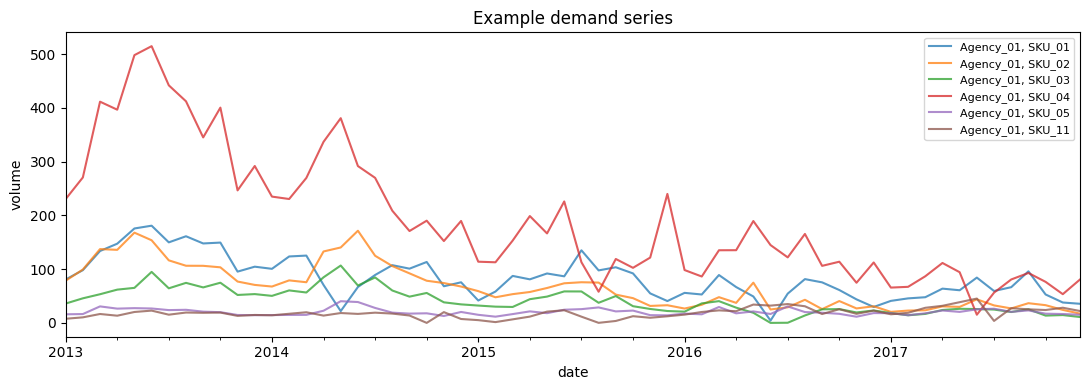

In [42]:
fig, ax = plt.subplots(figsize=(11, 4))

for (agency, sku), group in data.groupby(['agency', 'sku'], observed=True):
    label = f'{agency}, {sku}'
    group.sort_values('date').plot(x='date', y='volume', ax=ax, label=label, alpha=0.75)
    if len(ax.lines) >= 6:
        break

ax.set_title('Example demand series')
ax.set_xlabel('date')
ax.set_ylabel('volume')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The example series show different demand levels and different volatility across agency-SKU pairs. This supports using a panel model with static store-product context instead of one single unconditioned time series.

From the lecture we have the general TFT mapping shown below. The important part is not the particular energy dataset, but the split into static features, known time-varying features and unknown time-varying features.

In [43]:
# shortened lecture setup:
# target = 'energy'
# group_ids = ['group']
# time_varying_known_categoricals = ['hour', 'dow']
# time_varying_unknown_reals = ['temperature', 'energy']
# target_normalizer = GroupNormalizer(groups=['group'])

In [44]:
tft_features = [
    "agency", "sku",
    "avg_population_2017", "avg_yearly_household_income_2017",
    "time_idx", "month", "discount_in_percent",
    *special_days,
    "volume", "log_volume", "industry_volume", "soda_volume",
    "avg_max_temp", "avg_volume_by_sku", "avg_volume_by_agency",
]

feature_examples = pd.DataFrame({
    "feature": tft_features,
    "example values": [
        ", ".join(data[col].dropna().astype(str).drop_duplicates().head(3))
        for col in tft_features
    ],
})

feature_examples

,feature,example values
0,agency,"Agency_01, Agency_02, Agency_03"
1,sku,"SKU_01, SKU_02, SKU_03"
2,avg_population_2017,"153733, 3137874, 1538040"
3,avg_yearly_household_income_2017,"120207, 240809, 217280"
4,time_idx,"0, 1, 2"
5,month,"1, 2, 3"
6,discount_in_percent,"9.467128252299606, 9.7724552759124, 7.89195372..."
7,easter_day,"-, easter_day"
8,good_friday,"-, good_friday"
9,new_year,"new_year, -"


for this dataset I modify this mapping directly:
- agency and SKU identify the static store-product context
- demographic columns describe store location context
- promotions and calendar variables are known in advance
- past sales and market variables are only known historically

In [45]:
max_prediction_length = 6
max_encoder_length = 24

max_time_idx = data['time_idx'].max()
test_cutoff = max_time_idx - max_prediction_length
validation_cutoff = test_cutoff - max_prediction_length

tft_dataset_kwargs = dict(
    time_idx='time_idx',
    target='volume',
    group_ids=['agency', 'sku'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['agency', 'sku'],
    static_reals=['avg_population_2017', 'avg_yearly_household_income_2017'],
    time_varying_known_categoricals=['special_days', 'month'],
    variable_groups={'special_days': special_days},
    time_varying_known_reals=['time_idx', 'price_regular', 'discount_in_percent'],
    time_varying_unknown_reals=[
        'volume', 'log_volume', 'industry_volume', 'soda_volume',
        'avg_max_temp', 'avg_volume_by_agency', 'avg_volume_by_sku'
    ],
    target_normalizer=GroupNormalizer(groups=['agency', 'sku'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= validation_cutoff],
    **tft_dataset_kwargs,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    data[lambda x: x.time_idx <= test_cutoff],
    predict=True,
    stop_randomization=True,
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 4, num_workers=0)

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'condition': f'time_idx <= {validation_cutoff}',
        'min_date': data.loc[data.time_idx <= validation_cutoff, 'date'].min(),
        'max_date': data.loc[data.time_idx <= validation_cutoff, 'date'].max(),
    },
    {
        'split': 'validation',
        'condition': f'{validation_cutoff} < time_idx <= {test_cutoff}',
        'min_date': data.loc[(data.time_idx > validation_cutoff) & (data.time_idx <= test_cutoff), 'date'].min(),
        'max_date': data.loc[(data.time_idx > validation_cutoff) & (data.time_idx <= test_cutoff), 'date'].max(),
    },
    {
        'split': 'test',
        'condition': f'time_idx > {test_cutoff}',
        'min_date': data.loc[data.time_idx > test_cutoff, 'date'].min(),
        'max_date': data.loc[data.time_idx > test_cutoff, 'date'].max(),
    },
])

split_summary

,split,condition,min_date,max_date
0,train,time_idx <= 47,2013-01-01,2016-12-01
1,validation,47 < time_idx <= 53,2017-01-01,2017-06-01
2,test,time_idx > 53,2017-07-01,2017-12-01


The split is chronological. The first part trains TFT, the next six months select the checkpoint and the final six months stay untouched for test evaluation. This follows the lecture recommendation to separate training, validation and test instead of tuning directly on the test horizon.

Before fitting TFT, I keep a naive baseline. It predicts the next values from the recent history. Additionaly we define WMAPE that means Weighted Mean Absolute Percentage Error:

$$
WMAPE = \frac{\sum_t |y_t - \hat{y}_t|}{\sum_t |y_t|} \cdot 100\%.
$$

It is more stable than regular MAPE for retail data, because MAPE can explode when actual sales are very small or equal to zero. WMAPE also gives more practical weight to high-volume products

In [46]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def actuals_from_loader(loader):
    return torch.cat([y[0] for _, y in loader]).detach().cpu().numpy().ravel()


def postprocess_forecast(y_pred):
    # sales cannot be negative, so every model uses the same business post-processing
    return np.maximum(np.asarray(y_pred), 0)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if not mask.any():
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = postprocess_forecast(y_pred).ravel()

    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }


start = time.perf_counter()
baseline_val_predictions = Baseline().predict(val_dataloader)
baseline_val_prediction_seconds = time.perf_counter() - start

baseline_val_predictions = postprocess_forecast(to_numpy(baseline_val_predictions).ravel())
baseline_val_actuals = actuals_from_loader(val_dataloader)
baseline_val_metrics = evaluate_forecast(baseline_val_actuals, baseline_val_predictions)

pd.DataFrame([{
    "RMSE": baseline_val_metrics["RMSE"],
    "MAE": baseline_val_metrics["MAE"],
    "MAPE": baseline_val_metrics["MAPE"],
    "WMAPE": baseline_val_metrics["WMAPE"],
    "prediction_time_s": baseline_val_prediction_seconds,
}], index=["Baseline validation"]).round(3)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


,RMSE,MAE,MAPE,WMAPE,prediction_time_s
Baseline validation,875.071,370.093,159.615997,24.982,0.113


The model follows the lecture setup, with a small enough configuration to make the training realistic in a notebook. As mentioned in the task description, we use quantile loss for probabilistic forecasting.

In [47]:
tft_model_params = dict(
    learning_rate          = 0.001, #you can also try 0.0001, 0.01 etc, professional way: lr_find()
    hidden_size            = 32,    #start with 16/32, increase if not enough
    attention_head_size    = 4,     #usually 1-4
    dropout                = 0.2,   #usually 0.1-0.3
    hidden_continuous_size = 16,    #set to <= hidden_size
    loss                   = QuantileLoss(quantiles=[0.1, 0.5, 0.9]), #probabilistic forecasts
    reduce_on_plateau_patience = 4,
)

tft = TemporalFusionTransformer.from_dataset(training, **tft_model_params)

print(f"Number of parameters: {tft.size() / 1e3:.1f}k")

Number of parameters: 96.4k


In [48]:
csv_logger = CSVLogger(save_dir="logs", name="tft_stallion")
#to log train/val losses - stored later e.g. in logs/tft_stallion/version_0/metrics.csv
#from this file, you can select "train_loss_epoch" and "val_loss" columns to plot train/val loss curves

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-tft-validation",
)

trainer = pl.Trainer(
    max_epochs             = 40,
    gradient_clip_val      = 0.1, #gradient clipping
    accelerator            = "auto", #<------"gpu" if GPU is available, else "cpu"; here "auto" chooses it automatically
    devices                = 1,
    log_every_n_steps      = 5,
    enable_progress_bar    = True,
    logger                 = csv_logger,
    enable_checkpointing   = True,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, mode="min"), #professional standard to stop when val_loss no longer improves
        LearningRateMonitor(logging_interval="epoch"),
        checkpoint_callback,
    ],
)

start = time.perf_counter()
trainer.fit(
    tft,
    train_dataloaders = train_dataloader, #other batch_sizes may be better for your case (32, 128)
    val_dataloaders   = val_dataloader,
)
tft_validation_training_seconds = time.perf_counter() - start

if checkpoint_callback.best_model_path:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(checkpoint_callback.best_model_path)
else:
    best_tft = tft

print(f"TFT validation training time: {tft_validation_training_seconds:.2f}s")
print(f"Best checkpoint path: {checkpoint_callback.best_model_path}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.3 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    512 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 10.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 23.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  8.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     99 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 96.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 96.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 485                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

TFT validation training time: 413.70s
Best checkpoint path: logs/tft_stallion/version_3/checkpoints/best-tft-validation.ckpt


The logged loss curves are not the final evaluation, but they are useful for checking whether the model converged instead of only memorising noise. The checkpoint above keeps the best validation model, so the last epoch is not used blindly.

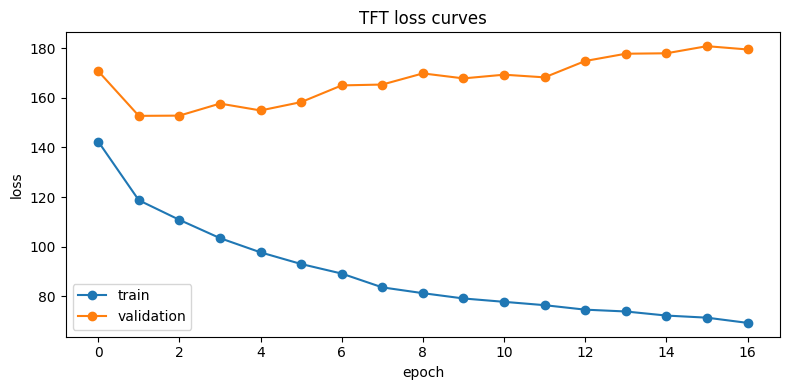

Best validation epoch for final refit: 2


In [49]:
metrics_path = os.path.join(csv_logger.log_dir, 'metrics.csv')
metrics = pd.read_csv(metrics_path)

fig, ax = plt.subplots(figsize=(8, 4))

if 'train_loss_epoch' in metrics.columns:
    train_loss = metrics.dropna(subset=['train_loss_epoch'])[['epoch', 'train_loss_epoch']]
    ax.plot(train_loss['epoch'], train_loss['train_loss_epoch'], marker='o', label='train')

if 'val_loss' in metrics.columns:
    val_loss = metrics.dropna(subset=['val_loss'])[['epoch', 'val_loss']]
    ax.plot(val_loss['epoch'], val_loss['val_loss'], marker='o', label='validation')

ax.set_title('TFT loss curves')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.show()

if 'val_loss' in metrics.columns and not metrics['val_loss'].dropna().empty:
    val_loss_clean = metrics.dropna(subset=['val_loss'])[['epoch', 'val_loss']]
    tft_best_epoch = int(val_loss_clean.loc[val_loss_clean['val_loss'].idxmin(), 'epoch']) + 1
else:
    tft_best_epoch = int(trainer.current_epoch) + 1

tft_best_epoch = max(1, tft_best_epoch)
print(f"Best validation epoch for final refit: {tft_best_epoch}")

The loss curves show clear overfitting during the validation run. Training loss decreases steadily from to about 70, while validation loss first drops in the first epoch and then gradually increases up to around 180. This means that the last epoch is not the best model state, so evaluating the final training epoch would give an unfairly weak TFT result. To handle this, the notebook keeps the best validation checkpoint instead of trusting the last epoch. The best epoch count is then reused for the final TFT refit on all observations before the test cutoff.

For the final test horizon I refit the same TFT architecture on all data before the test cutoff. This fixes the comparison issue: ARIMA, Prophet, LSTM and TFT all train on the same train plus validation range and predict the same final six months.

In [50]:
training_final = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= test_cutoff],
    **tft_dataset_kwargs,
)

final_monitor = TimeSeriesDataSet.from_dataset(
    training_final,
    data[lambda x: x.time_idx <= test_cutoff],
    predict=True,
    stop_randomization=True,
)

test = TimeSeriesDataSet.from_dataset(
    training_final,
    data,
    predict=True,
    stop_randomization=True,
)

final_train_dataloader = training_final.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
final_monitor_dataloader = final_monitor.to_dataloader(train=False, batch_size=batch_size * 4, num_workers=0)
test_dataloader = test.to_dataloader(train=False, batch_size=batch_size * 4, num_workers=0)

tft_final = TemporalFusionTransformer.from_dataset(training_final, **tft_model_params)

trainer_final = pl.Trainer(
    max_epochs             = tft_best_epoch,
    gradient_clip_val      = 0.1,
    accelerator            = "auto",
    devices                = 1,
    enable_progress_bar    = True,
    logger                 = False,
    enable_checkpointing   = False,
)

start = time.perf_counter()
trainer_final.fit(
    tft_final,
    train_dataloaders = final_train_dataloader,
    val_dataloaders   = final_monitor_dataloader,
)
tft_final_training_seconds = time.perf_counter() - start

tft_model_for_test = tft_final
tft_training_seconds = tft_validation_training_seconds + tft_final_training_seconds

print(f"TFT final refit time: {tft_final_training_seconds:.2f}s")
print(f"TFT total modelling time: {tft_training_seconds:.2f}s")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.3 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    512 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 10.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 23.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  8.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     99 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 96.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 96.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 485                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=2` reached.


TFT final refit time: 54.48s
TFT total modelling time: 468.18s


In [51]:
start = time.perf_counter()
baseline_test_predictions = Baseline().predict(test_dataloader)
baseline_test_prediction_seconds = time.perf_counter() - start

start = time.perf_counter()
tft_point_predictions = tft_model_for_test.predict(test_dataloader)
tft_prediction_seconds = time.perf_counter() - start

test_true = actuals_from_loader(test_dataloader)

baseline_test_pred = postprocess_forecast(to_numpy(baseline_test_predictions).ravel())
tft_pred = postprocess_forecast(to_numpy(tft_point_predictions).ravel())

baseline_test_metrics = evaluate_forecast(test_true, baseline_test_pred)
tft_metrics = evaluate_forecast(test_true, tft_pred)

tft_vs_baseline = pd.DataFrame([
    {
        "model": "Baseline",
        "RMSE": baseline_test_metrics["RMSE"],
        "MAE": baseline_test_metrics["MAE"],
        "MAPE": baseline_test_metrics["MAPE"],
        "WMAPE": baseline_test_metrics["WMAPE"],
        "training_time_s": 0.0,
        "prediction_time_s": baseline_test_prediction_seconds,
    },
    {
        "model": "TFT",
        "RMSE": tft_metrics["RMSE"],
        "MAE": tft_metrics["MAE"],
        "MAPE": tft_metrics["MAPE"],
        "WMAPE": tft_metrics["WMAPE"],
        "training_time_s": tft_training_seconds,
        "prediction_time_s": tft_prediction_seconds,
    },
])

tft_vs_baseline.set_index("model").round(3)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note tha

,RMSE,MAE,MAPE,WMAPE,training_time_s,prediction_time_s
model,,,,,,
Baseline,748.482,293.009,124.042000,18.719999,0.000,0.117
TFT,663.224,266.086,92.080002,17.000000,468.182,0.247


The table confirms that TFT improves over the naive baseline on every error metric. RMSE decreases from +-750 to +-650, MAE from +-300 to +-265, MAPE from +-125% to +-90%. This means that the model adds value not only for large-error cases, measured by RMSE, but also for average absolute errors. The improvement is not free: TFT needs a lot more seconds of training.

In [52]:
tft_improvement = pd.DataFrame([{
    "RMSE_improvement_%":  (1 - tft_metrics["RMSE"]  / baseline_test_metrics["RMSE"])  * 100,
    "MAE_improvement_%":   (1 - tft_metrics["MAE"]   / baseline_test_metrics["MAE"])   * 100,
    "MAPE_improvement_%":  (1 - tft_metrics["MAPE"]  / baseline_test_metrics["MAPE"])  * 100,
    "WMAPE_improvement_%": (1 - tft_metrics["WMAPE"] / baseline_test_metrics["WMAPE"]) * 100,
}], index=["TFT vs Baseline"])

tft_improvement.round(2)

,RMSE_improvement_%,MAE_improvement_%,MAPE_improvement_%,WMAPE_improvement_%
TFT vs Baseline,11.39,9.19,25.77,9.19


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


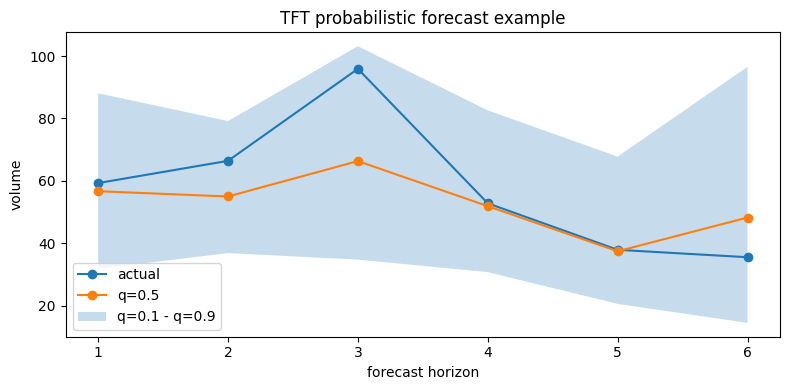

In [53]:
quantile_predictions = to_numpy(tft_model_for_test.predict(test_dataloader, mode='quantiles'))
first_actual = next(iter(test_dataloader))[1][0][0].detach().cpu().numpy()
first_quantiles = quantile_predictions[0]

horizon = np.arange(1, max_prediction_length + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(horizon, first_actual, marker='o', label='actual')
ax.plot(horizon, first_quantiles[:, 1], marker='o', label='q=0.5')
ax.fill_between(horizon, first_quantiles[:, 0], first_quantiles[:, 2], alpha=0.25, label='q=0.1 - q=0.9')
ax.set_title('TFT probabilistic forecast example')
ax.set_xlabel('forecast horizon')
ax.set_ylabel('volume')
ax.legend()
plt.tight_layout()
plt.show()

The median forecast gives the point prediction, while the 0.1 and 0.9 quantiles show uncertainty around it. This is useful in retail because inventory decisions depend on risk, not only on one expected value. A wider interval means the model is less certain about future demand.

TFT is useful here not only because it forecasts many related series at once. The architecture also stores information about variable selection, so we can inspect which static and time-varying features mattered most.

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


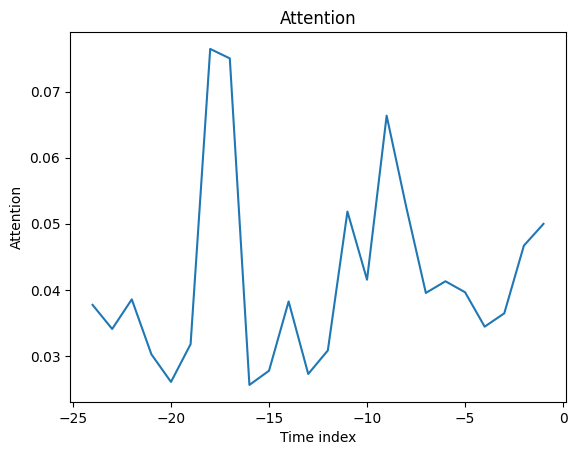

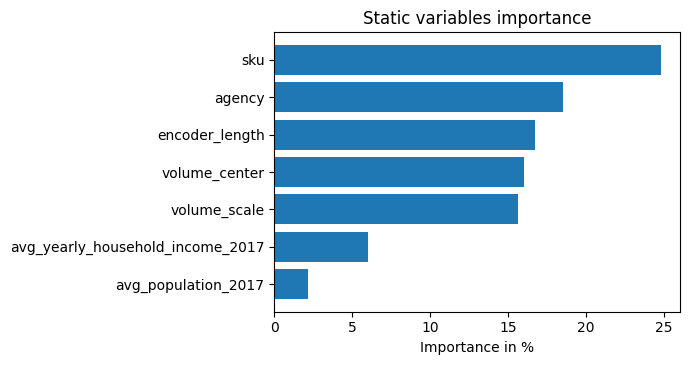

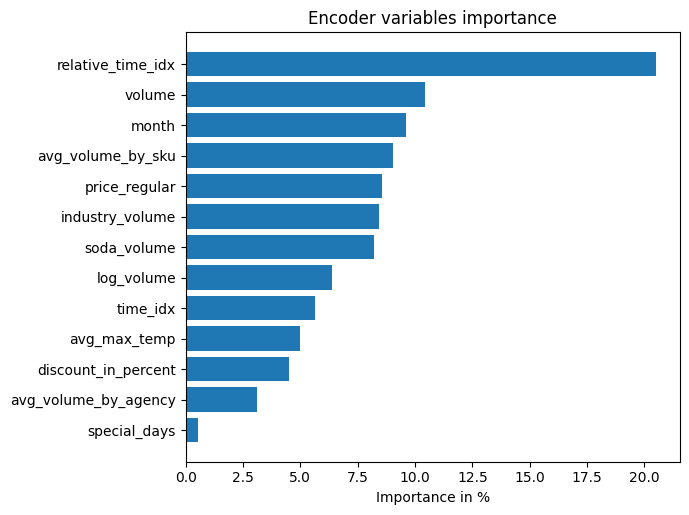

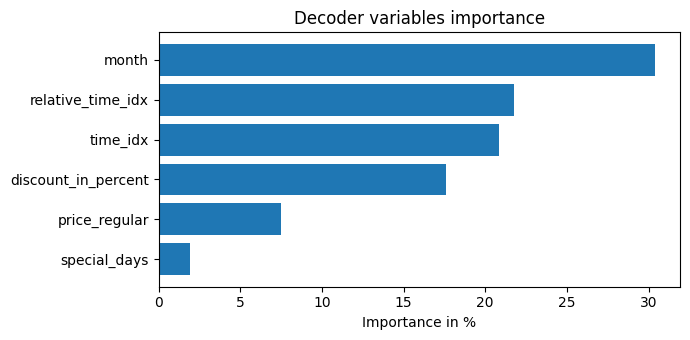

In [54]:
raw_preds = tft_model_for_test.predict(test_dataloader, mode='raw', return_x=True)
interpretation = tft_model_for_test.interpret_output(raw_preds.output, reduction='sum')

tft_model_for_test.plot_interpretation(interpretation)
plt.tight_layout()
plt.show()

The interpretation plots show that the TFT model uses both static series identity and time-dependent information. The attention plot has several local peaks, which means the model does not rely on only one previous month but combines information from different historical positions.

Static variable importance is dominated by `sku`, followed by `encoder_length`, `agency`, and target normalization parameters. This means that persistent differences between products and store locations are important for separating demand levels across series. Demographic location features have lower importance, so they add context but are less decisive than product and agency identity.

For encoder variables, `relative_time_idx`, historical `volume`, `price_regular`, `month`, and product-level average volume are the most important inputs. This suggests that the model mainly learns from recent demand history, seasonal position, price level, and typical product scale. Promotion and special-day effects are weaker in the encoder.

For decoder variables, `month` is clearly the most important known future feature, followed by time index variables and `discount_in_percent`. This is consistent with retail forecasting: future seasonality and planned promotions are useful because they are known before the forecast horizon. `special_days` has low importance in this run.

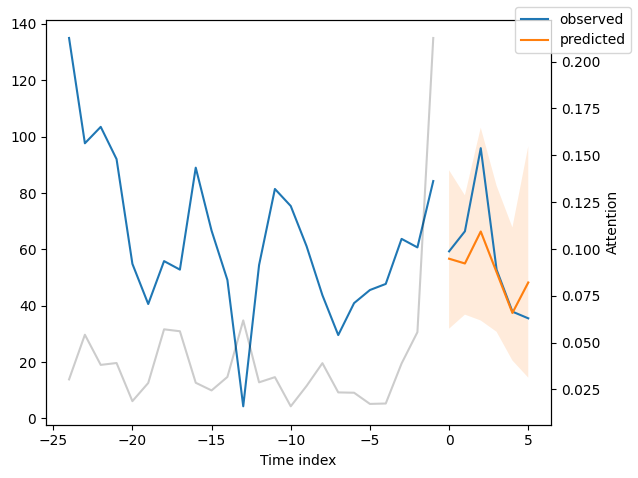

In [55]:
idx = 0 #as an example: first available forecast window in the test set

tft_model_for_test.plot_prediction(
    raw_preds.x,
    raw_preds.output,
    idx=idx,
);

This example forecast shows that the TFT model captures the general downward movement over the 6-month horizon. This means the model learned the local demand level reasonably well, but it still smooths sharp month-to-month changes. shaded prediction interval represents forecast uncertainty between lower and upper quantiles. All observed values remain inside or close to this interval, which suggests that the probabilistic forecast is useful for risk-aware planning.

# Problem 4.4: Model Comparison

## Objective

Comprehensive evaluation of time series models

## Tasks

- Compare ARIMA, Prophet, LSTM, and TFT on same dataset.
- Evaluate using RMSE, MAE, and MAPE.
- Analyze computational costs.
- Provide recommendations for different use cases.

For the comparison we use the same dataset as in problem 4.3.

The final protocol is now consistent: every model is trained only on observations up to the test cutoff and predicts the same final six-month horizon. ARIMA and Prophet are fitted separately for every agency-SKU series, while LSTM and TFT learn from the panel structure.

In [56]:
comparison_results = []


def add_result(model_name, y_true, y_pred, train_seconds, prediction_seconds=0.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = postprocess_forecast(y_pred).ravel()

    comparison_results.append({
        'model': model_name,
        'RMSE': rmse(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred),
        'WMAPE': wmape(y_true, y_pred),
        'training_time_s': train_seconds,
        'prediction_time_s': prediction_seconds,
        'total_time_s': train_seconds + prediction_seconds,
    })

ARIMA is a classical baseline. It cannot use the panel structure or static variables.

In [57]:
arima_orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

arima_true, arima_pred = [], []
selected_orders = []
arima_training_seconds = 0.0
arima_prediction_seconds = 0.0

for _, group in data.groupby(["agency", "sku"], observed=True):
    group = group.sort_values("time_idx")

    train_y = group[group.time_idx <= test_cutoff]["volume"].to_numpy()
    test_y  = group[group.time_idx >  test_cutoff]["volume"].to_numpy()

    best_fit, best_order, best_aic = None, None, np.inf

    start = time.perf_counter()
    for order in arima_orders:
        try:
            fit = ARIMA(train_y, order=order).fit()
            if fit.aic < best_aic:
                best_fit, best_order, best_aic = fit, order, fit.aic
        except Exception:
            pass
    arima_training_seconds += time.perf_counter() - start

    if best_fit is None:
        continue

    start = time.perf_counter()
    pred = best_fit.forecast(steps=len(test_y))
    arima_prediction_seconds += time.perf_counter() - start

    arima_true.extend(test_y)
    arima_pred.extend(pred)
    selected_orders.append(best_order)

add_result("ARIMA(AIC)", arima_true, arima_pred, arima_training_seconds, arima_prediction_seconds)

print(f"ARIMA training time: {arima_training_seconds:.2f}s")
print(f"ARIMA prediction time: {arima_prediction_seconds:.2f}s")
pd.Series(selected_orders).value_counts()

ARIMA training time: 22.96s
ARIMA prediction time: 0.21s


(0, 1, 1)    167
(1, 1, 1)     78
(2, 1, 1)     40
(1, 1, 2)     35
(1, 1, 0)     30
Name: count, dtype: int64

Selected ARIMA orders differ across agency-SKU series, which confirms that the panel is heterogeneous. ARIMA is a strong classical baseline for short local series, but it cannot use promotions, holidays or shared learning across products.

Prophet is still fitted per series, but it has built-in seasonality and can use discount information as an additional regressor. This is closer to retail practice than pure ARIMA, although it still ignores shared learning between products. I add the discount percentage as an external regressor, because planned discounts are known for the forecast horizon.

In [58]:
prophet_true, prophet_pred = [], []
prophet_failed = 0
prophet_training_seconds = 0.0
prophet_prediction_seconds = 0.0

for _, group in data.groupby(["agency", "sku"], observed=True):
    group = group.sort_values("date")
    train_part = group[group.time_idx <= test_cutoff]
    test_part  = group[group.time_idx >  test_cutoff]

    if len(train_part) < 12 or len(test_part) == 0:
        continue

    train_df = train_part[["date", "volume", "discount_in_percent"]].rename(
        columns={"date": "ds", "volume": "y"}
    )
    future_df = test_part[["date", "discount_in_percent"]].rename(
        columns={"date": "ds"}
    )

    try:
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
        )
        model.add_regressor("discount_in_percent")

        start = time.perf_counter()
        model.fit(train_df)
        prophet_training_seconds += time.perf_counter() - start

        start = time.perf_counter()
        forecast = model.predict(future_df)
        prophet_prediction_seconds += time.perf_counter() - start

        prophet_true.extend(test_part["volume"].to_numpy())
        prophet_pred.extend(forecast["yhat"].to_numpy())
    except Exception:
        prophet_failed += 1

add_result("Prophet", prophet_true, prophet_pred, prophet_training_seconds, prophet_prediction_seconds)

print(f"Prophet training time: {prophet_training_seconds:.2f}s")
print(f"Prophet prediction time: {prophet_prediction_seconds:.2f}s")
print(f"Failed series: {prophet_failed}")

Prophet training time: 33.19s
Prophet prediction time: 7.02s
Failed series: 0


Prophet is fitted separately for each series, but it can use planned discounts as a regressor. This makes it closer to a retail forecasting use case than pure ARIMA. The cost is that training time grows almost linearly with the number of series.

The LSTM baseline uses the same encoder and prediction lengths as TFT. It sees multivariate historical windows and returns the whole six-month horizon at once, but without the explicit variable selection and attention mechanisms of TFT.

In [59]:
data_lstm = data.copy()
data_lstm["volume_original"] = data_lstm["volume"]

data_lstm["month_num"] = data_lstm["date"].dt.month
data_lstm["month_sin"] = np.sin(2 * np.pi * data_lstm["month_num"] / 12)
data_lstm["month_cos"] = np.cos(2 * np.pi * data_lstm["month_num"] / 12)

data_lstm["is_special_day"] = (
    data_lstm[special_days]
    .ne("-")
    .any(axis=1)
    .astype(int)
)

lstm_features = [
    "volume",
    "log_volume",
    "discount_in_percent",
    "price_regular",
    "industry_volume",
    "soda_volume",
    "avg_max_temp",
    "avg_volume_by_sku",
    "avg_volume_by_agency",
    "avg_population_2017",
    "avg_yearly_household_income_2017",
    "month_sin",
    "month_cos",
    "is_special_day",
]

train_rows = data_lstm.time_idx <= test_cutoff

x_scaler = StandardScaler().fit(data_lstm.loc[train_rows, lstm_features])
y_scaler = StandardScaler().fit(data_lstm.loc[train_rows, ["volume_original"]])

data_lstm[lstm_features] = x_scaler.transform(data_lstm[lstm_features])
data_lstm["target_scaled"] = y_scaler.transform(data_lstm[["volume_original"]])

In [60]:
def make_lstm_windows(df):
    X_train, y_train, X_test, y_test = [], [], [], []

    for _, group in df.groupby(['agency', 'sku'], observed=True):
        group = group.sort_values('time_idx')
        x_values = group[lstm_features].to_numpy(dtype=np.float32)
        y_scaled = group['target_scaled'].to_numpy(dtype=np.float32)
        y_original = group["volume_original"].to_numpy(dtype=np.float32)
        times = group['time_idx'].to_numpy()

        for start_idx in range(len(group) - max_encoder_length - max_prediction_length + 1):
            pred_slice = slice(start_idx + max_encoder_length, start_idx + max_encoder_length + max_prediction_length)
            if times[pred_slice][-1] <= test_cutoff:
                X_train.append(x_values[start_idx:start_idx + max_encoder_length])
                y_train.append(y_scaled[pred_slice])

        test_start = np.where(times == test_cutoff)[0][0] - max_encoder_length + 1
        test_pred_start = test_start + max_encoder_length
        X_test.append(x_values[test_start:test_start + max_encoder_length])
        y_test.append(y_original[test_pred_start:test_pred_start + max_prediction_length])

    return map(np.asarray, (X_train, y_train, X_test, y_test))


X_train, y_train, X_test, y_test = make_lstm_windows(data_lstm)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [61]:
class MultiStepLSTM(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.2, horizon=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden, layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, horizon),
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

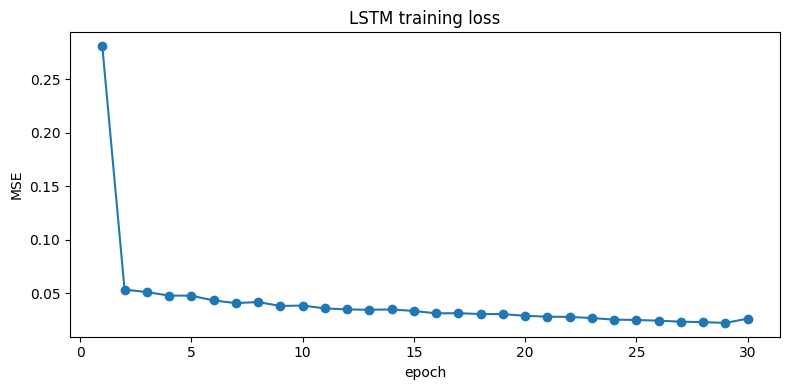

LSTM training time: 18.24s


In [62]:
start = time.perf_counter()

lstm = MultiStepLSTM(
    input_size=len(lstm_features),
    hidden=64,
    layers=2,
    horizon=max_prediction_length,
).to(device)

optimizer = torch.optim.Adam(lstm.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
lstm_losses = []

for epoch in range(30):
    lstm.train()
    epoch_losses = []

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(lstm(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    lstm_losses.append(np.mean(epoch_losses))

lstm_training_seconds = time.perf_counter() - start

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(lstm_losses) + 1), lstm_losses, marker='o')
ax.set_title('LSTM training loss')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE')
plt.tight_layout()
plt.show()

print(f'LSTM training time: {lstm_training_seconds:.2f}s')

The LSTM loss should decrease and then stabilize. This model learns from the whole panel and is cheaper than TFT, but it has no built-in variable importance and no direct quantile forecasts. It is a useful neural baseline rather than a fully interpretable forecasting system.

In [63]:
start = time.perf_counter()

lstm.eval()
with torch.no_grad():
    lstm_scaled_pred = lstm(X_test_tensor).cpu().numpy()

lstm_prediction_seconds = time.perf_counter() - start
lstm_pred = postprocess_forecast(y_scaler.inverse_transform(lstm_scaled_pred.reshape(-1, 1)).ravel())
lstm_true = y_test.reshape(-1)

add_result('LSTM', lstm_true, lstm_pred, lstm_training_seconds, lstm_prediction_seconds)
print('LSTM RMSE:', rmse(lstm_true, lstm_pred).round(3))

LSTM RMSE: 677.851


For TFT I reuse the final model from Problem 4.3. It was refitted on the same train plus validation range as ARIMA, Prophet and LSTM, so the comparison is no longer biased by a shorter TFT training window.

In [64]:
add_result("TFT", test_true, tft_pred, tft_training_seconds, tft_prediction_seconds)

comparison = pd.DataFrame(comparison_results)
comparison = comparison[[
    'model', 'RMSE', 'MAE', 'MAPE', 'WMAPE', 'training_time_s', 'prediction_time_s', 'total_time_s'
]].sort_values('RMSE').reset_index(drop=True)

comparison_rounded = comparison.copy()
comparison_rounded[['RMSE', 'MAE', 'MAPE', 'WMAPE', 'training_time_s', 'prediction_time_s', 'total_time_s']] = comparison_rounded[
    ['RMSE', 'MAE', 'MAPE', 'WMAPE', 'training_time_s', 'prediction_time_s', 'total_time_s']
].round(3)

comparison_rounded

,model,RMSE,MAE,MAPE,WMAPE,training_time_s,prediction_time_s,total_time_s
0,Prophet,650.424,269.543,363.178,17.221,33.193,7.018,40.211
1,TFT,663.224,266.086,92.080,17.000,468.182,0.247,468.429
2,ARIMA(AIC),674.357,259.896,212.088,16.605,22.962,0.207,23.169
3,LSTM,677.851,300.356,832.941,19.190,18.243,0.004,18.248


The table ranks models on the same final six-month test horizon. RMSE and MAE are the main metrics because they are stable in sales units. MAPE is still reported because it is required, but WMAPE is safer for retail data with low or zero sales.

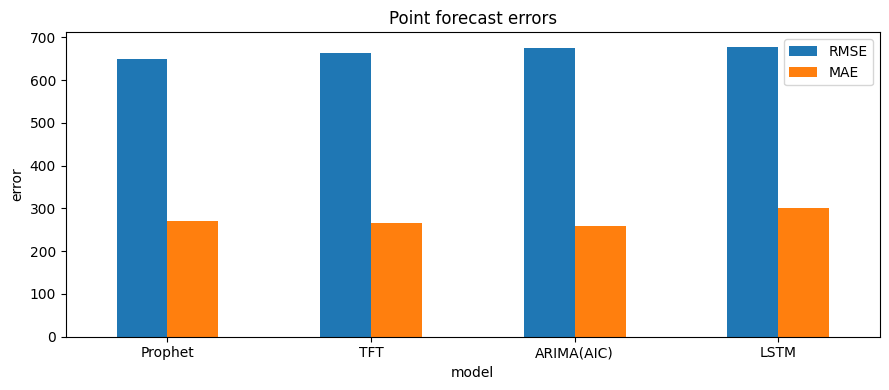

In [65]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison.set_index('model')[['RMSE', 'MAE']].plot(kind='bar', ax=ax)
ax.set_title('Point forecast errors')
ax.set_ylabel('error')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The error chart shows that all models are close in RMSE and MAE. 

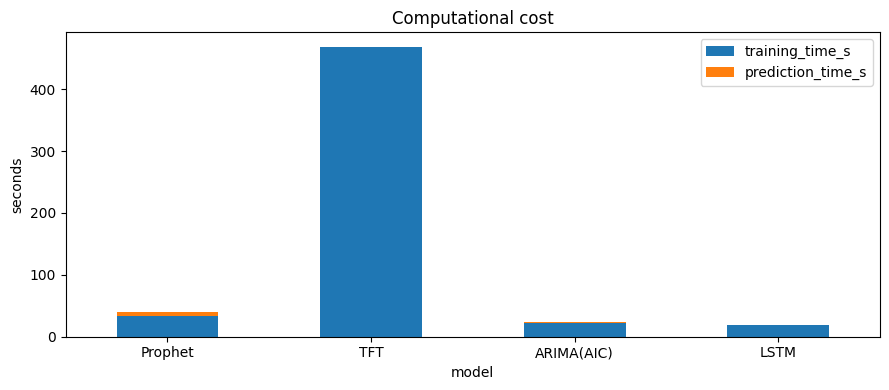

In [66]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison.set_index('model')[['training_time_s', 'prediction_time_s']].plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Computational cost')
ax.set_ylabel('seconds')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The computational cost plot shows the main practical difference between the models. TFT is clearly the most expensive option, requiring more than 470 seconds of training, while Prophet, ARIMA and LSTM are much faster on this dataset. Prediction time is small for all models compared with training time, so the main deployment cost comes from model fitting and retraining.

Since the accuracy results are relatively close, the computational cost becomes an important selection criterion. For a compact monthly retail dataset, simpler models can be preferable when similar accuracy is enough and fast retraining matters. TFT is still useful when we also need probabilistic forecasts, variable importance and a single global model, but its higher training cost should be justified by these extra benefits rather than by point-forecast accuracy alone.